In [1]:
"""
Probing for Harmful Intent in Transformer Activations
=====================================================
Each # ====== CELL N ====== block is one Colab cell.
Run top to bottom on a T4 GPU runtime.

Models: SmolLM3-3B-Base (base) vs SmolLM3-3B (safety-tuned)
Same architecture, same tokenizer — only training differs.

Dataset: data_v7.csv — 128 prompts, 4 families, 4 harm levels.
Vocabulary AND syntax controlled across levels.

Fixes applied:
  - Mean-pooling over non-padding tokens (not last-token)
  - Embedding layer included (hidden_states[0:])
  - GroupKFold CV (no leakage from similar prompts)
  - StandardScaler in all pipelines
  - Diff-of-means cross-validated
  - Shuffled-label check uses same pipeline
  - Same architecture for base vs safety comparison
  - pad_token set for both tokenizers
  - Cross-family generalisation for both models
"""

'\nProbing for Harmful Intent in Transformer Activations\n=====================================================\nEach # ====== CELL N ====== block is one Colab cell.\nRun top to bottom on a T4 GPU runtime.\n\nModels: SmolLM3-3B-Base (base) vs SmolLM3-3B (safety-tuned)\nSame architecture, same tokenizer — only training differs.\n\nDataset: data_v7.csv — 128 prompts, 4 families, 4 harm levels.\nVocabulary AND syntax controlled across levels.\n\nFixes applied:\n  - Mean-pooling over non-padding tokens (not last-token)\n  - Embedding layer included (hidden_states[0:])\n  - GroupKFold CV (no leakage from similar prompts)\n  - StandardScaler in all pipelines\n  - Diff-of-means cross-validated\n  - Shuffled-label check uses same pipeline\n  - Same architecture for base vs safety comparison\n  - pad_token set for both tokenizers\n  - Cross-family generalisation for both models\n'

In [2]:
# ====== CELL 1 — Install dependencies ======
!pip install -q transformers accelerate scikit-learn matplotlib


In [3]:

# ====== CELL 2 — Imports and device check ======
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [4]:

# ====== CELL 3 — Load dataset ======
# Option A: upload manually
from google.colab import files
uploaded = files.upload()  # select data_v7.csv

# Option B: mount Google Drive (uncomment if preferred)
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv("/content/drive/MyDrive/data_v7.csv")

DATASET_FILE = "data_v7.csv"
df = pd.read_csv(DATASET_FILE)
df["label"] = (df["level"] >= 2).astype(int)
y = df["label"].values

# Groups for GroupKFold: topic chains across levels.
# Each family has 8 topics (e.g. chlorine, alkaloids, organophosphates...).
# Prompt i within a family+level maps to topic_id = i % 8.
# All 4 harm-level variants of the same topic get the same group,
# so paraphrases / near-duplicates never leak across folds.
df["topic_idx"] = df.groupby(["family", "level"]).cumcount()  # 0-7 within each family+level
groups = (df["family"] + "_topic" + df["topic_idx"].astype(str)).values
# This gives 4 families × 8 topics = 32 groups.
# Each group has 4 prompts (one per level): mixed labels guaranteed.

print(f"Loaded {len(df)} prompts from {DATASET_FILE}")
print(f"Families: {sorted(df['family'].unique())}")
print(f"Label balance: {df.groupby('label').size().to_dict()}")
print(f"Groups: {len(np.unique(groups))} unique (should be 32)")
print(f"Prompts per group: {len(df) // len(np.unique(groups))} (should be 4)")


Saving data_v7.csv to data_v7.csv
Loaded 128 prompts from data_v7.csv
Families: ['chem', 'phys', 'sec', 'social']
Label balance: {0: 64, 1: 64}
Groups: 32 unique (should be 32)
Prompts per group: 4 (should be 4)


In [5]:

# ====== CELL 4 — Load base model ======
MODEL_BASE = "HuggingFaceTB/SmolLM3-3B-Base"
print(f"Loading {MODEL_BASE} ...")
tokenizer_base = AutoTokenizer.from_pretrained(MODEL_BASE)
tokenizer_base.pad_token = tokenizer_base.eos_token
model_base = AutoModelForCausalLM.from_pretrained(
    MODEL_BASE,
    torch_dtype=torch.float16,
    device_map="auto",
    output_hidden_states=True,
)
model_base.config.pad_token_id = tokenizer_base.pad_token_id
print(f"Loaded: {model_base.config.num_hidden_layers} layers, "
      f"d_model={model_base.config.hidden_size}")


Loading HuggingFaceTB/SmolLM3-3B-Base ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/943 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/326 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

Loaded: 36 layers, d_model=2048


In [6]:

# ====== CELL 5 — Extraction function + extract base model activations ======
def extract_activations(model, tokenizer, prompts, batch_size=4):
    """
    Extract residual stream activations for each prompt at every layer.

    Three pooling strategies collected simultaneously:
      - mean_all:  mean over all non-padding tokens
      - mean_last8: mean over last 8 non-padding tokens
      - last_token: single last non-padding token

    Includes embedding layer (hidden_states[0]).
    Returns dict of arrays, each shape [n_prompts, n_layers+1, d_model].
    """
    all_mean = []
    all_last8 = []
    all_last = []
    for i in range(0, len(prompts), batch_size):
        batch = prompts[i : i + batch_size]
        inputs = tokenizer(
            batch, return_tensors="pt", padding=True,
            truncation=True, max_length=512
        ).to(model.device)
        with torch.no_grad():
            outputs = model(**inputs)
        hidden_states = outputs.hidden_states
        attention_mask = inputs["attention_mask"]
        for j in range(len(batch)):
            mask = attention_mask[j].bool()
            n_real = mask.sum().item()
            layers_mean, layers_last8, layers_last = [], [], []
            for layer_hs in hidden_states:
                real_acts = layer_hs[j, mask, :]  # [n_real, d_model]
                # Mean over all tokens
                layers_mean.append(real_acts.mean(dim=0).cpu().float().numpy())
                # Mean over last 8 tokens (or fewer if prompt is shorter)
                k = min(8, n_real)
                layers_last8.append(real_acts[-k:].mean(dim=0).cpu().float().numpy())
                # Last token only
                layers_last.append(real_acts[-1].cpu().float().numpy())
            all_mean.append(np.stack(layers_mean))
            all_last8.append(np.stack(layers_last8))
            all_last.append(np.stack(layers_last))
        del outputs
        torch.cuda.empty_cache()
        if (i // batch_size) % 5 == 0:
            print(f"  {min(i + batch_size, len(prompts))}/{len(prompts)}")
    return {
        "mean_all": np.stack(all_mean),
        "mean_last8": np.stack(all_last8),
        "last_token": np.stack(all_last),
    }

print("Extracting base model activations ...")
acts_base_all = extract_activations(model_base, tokenizer_base, df["prompt"].tolist())
print(f"Shapes: { {k: v.shape for k, v in acts_base_all.items()} }")
# Default pooling for main analysis
POOLING = "mean_last8"  # change to "mean_all" or "last_token" to compare
acts_base = acts_base_all[POOLING]



Extracting base model activations ...
  4/128
  24/128
  44/128
  64/128
  84/128
  104/128
  124/128
Shapes: {'mean_all': (128, 37, 2048), 'mean_last8': (128, 37, 2048), 'last_token': (128, 37, 2048)}


In [7]:
# ====== CELL 6 — Free memory, load safety-tuned model ======
del model_base
torch.cuda.empty_cache()

MODEL_SAFE = "HuggingFaceTB/SmolLM3-3B"
print(f"Loading {MODEL_SAFE} ...")
tokenizer_safe = AutoTokenizer.from_pretrained(MODEL_SAFE)
tokenizer_safe.pad_token = tokenizer_safe.eos_token
model_safe = AutoModelForCausalLM.from_pretrained(
    MODEL_SAFE,
    torch_dtype=torch.float16,
    device_map="auto",
    output_hidden_states=True,
)
model_safe.config.pad_token_id = tokenizer_safe.pad_token_id
print(f"Loaded: {model_safe.config.num_hidden_layers} layers, "
      f"d_model={model_safe.config.hidden_size}")



Loading HuggingFaceTB/SmolLM3-3B ...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/326 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/182 [00:00<?, ?B/s]

Loaded: 36 layers, d_model=2048


In [8]:

# ====== CELL 7 — Extract safety-tuned model activations ======
print("Extracting safety-tuned model activations ...")
acts_safe_all = extract_activations(model_safe, tokenizer_safe, df["prompt"].tolist())
print(f"Shapes: { {k: v.shape for k, v in acts_safe_all.items()} }")
acts_safe = acts_safe_all[POOLING]

del model_safe
torch.cuda.empty_cache()


Extracting safety-tuned model activations ...
  4/128
  24/128
  44/128
  64/128
  84/128
  104/128
  124/128
Shapes: {'mean_all': (128, 37, 2048), 'mean_last8': (128, 37, 2048), 'last_token': (128, 37, 2048)}


In [9]:

# ====== CELL 8 — Train probes per layer (GroupKFold CV) ======
def probe_all_layers(acts, y, groups, name):
    """Logistic regression probe per layer with GroupKFold CV."""
    n_layers = acts.shape[1]
    aucs, stds = [], []
    gkf = GroupKFold(n_splits=5)
    for layer in range(n_layers):
        X = acts[:, layer, :]
        fold_aucs = []
        for train_idx, test_idx in gkf.split(X, y, groups):
            pipe = make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=2000)
            )
            pipe.fit(X[train_idx], y[train_idx])
            y_prob = pipe.predict_proba(X[test_idx])[:, 1]
            fold_aucs.append(roc_auc_score(y[test_idx], y_prob))
        aucs.append(np.mean(fold_aucs))
        stds.append(np.std(fold_aucs))
    best = np.argmax(aucs)
    print(f"  {name}: best AUC = {aucs[best]:.3f} +/- {stds[best]:.3f} at layer {best}")
    return pd.DataFrame({"layer": range(n_layers), "auc_mean": aucs, "auc_std": stds})

print("=== Base model ===")
probe_base = probe_all_layers(acts_base, y, groups, "Base")
print("\n=== Safety-tuned model ===")
probe_safe = probe_all_layers(acts_safe, y, groups, "Safety-tuned")

# Print a few layers for quick inspection
for label, probe_df in [("Base", probe_base), ("Safety-tuned", probe_safe)]:
    print(f"\n  {label}:")
    for layer in range(0, len(probe_df), 8):
        row = probe_df.iloc[layer]
        print(f"    Layer {int(row['layer']):3d}: AUC = {row['auc_mean']:.3f} +/- {row['auc_std']:.3f}")


=== Base model ===
  Base: best AUC = 0.974 +/- 0.016 at layer 13

=== Safety-tuned model ===
  Safety-tuned: best AUC = 0.965 +/- 0.022 at layer 13

  Base:
    Layer   0: AUC = 0.723 +/- 0.077
    Layer   8: AUC = 0.940 +/- 0.045
    Layer  16: AUC = 0.961 +/- 0.027
    Layer  24: AUC = 0.950 +/- 0.037
    Layer  32: AUC = 0.927 +/- 0.049

  Safety-tuned:
    Layer   0: AUC = 0.725 +/- 0.075
    Layer   8: AUC = 0.947 +/- 0.051
    Layer  16: AUC = 0.942 +/- 0.038
    Layer  24: AUC = 0.950 +/- 0.041
    Layer  32: AUC = 0.914 +/- 0.044


In [12]:

# ====== CELL 9 — Shuffled-label sanity check (same pipeline) ======
layer_check = 0
X_check = acts_base[:, layer_check, :]
y_shuffled = np.random.permutation(y)
gkf = GroupKFold(n_splits=5)

real_aucs, shuf_aucs = [], []
for train_idx, test_idx in gkf.split(X_check, y, groups):
    # Real labels
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    pipe.fit(X_check[train_idx], y[train_idx])
    real_aucs.append(roc_auc_score(
        y[test_idx], pipe.predict_proba(X_check[test_idx])[:, 1]))
    # Shuffled labels — same pipeline
    pipe2 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    pipe2.fit(X_check[train_idx], y_shuffled[train_idx])
    shuf_aucs.append(roc_auc_score(
        y_shuffled[test_idx], pipe2.predict_proba(X_check[test_idx])[:, 1]))

print(f"Sanity check at layer {layer_check}:")
print(f"  Real labels:     {np.mean(real_aucs):.3f} +/- {np.std(real_aucs):.3f}")
print(f"  Shuffled labels: {np.mean(shuf_aucs):.3f} +/- {np.std(shuf_aucs):.3f}")
print(f"  (Shuffled should be ~0.5 — if not, probe is overfitting)")


Sanity check at layer 0:
  Real labels:     0.723 +/- 0.077
  Shuffled labels: 0.466 +/- 0.117
  (Shuffled should be ~0.5 — if not, probe is overfitting)


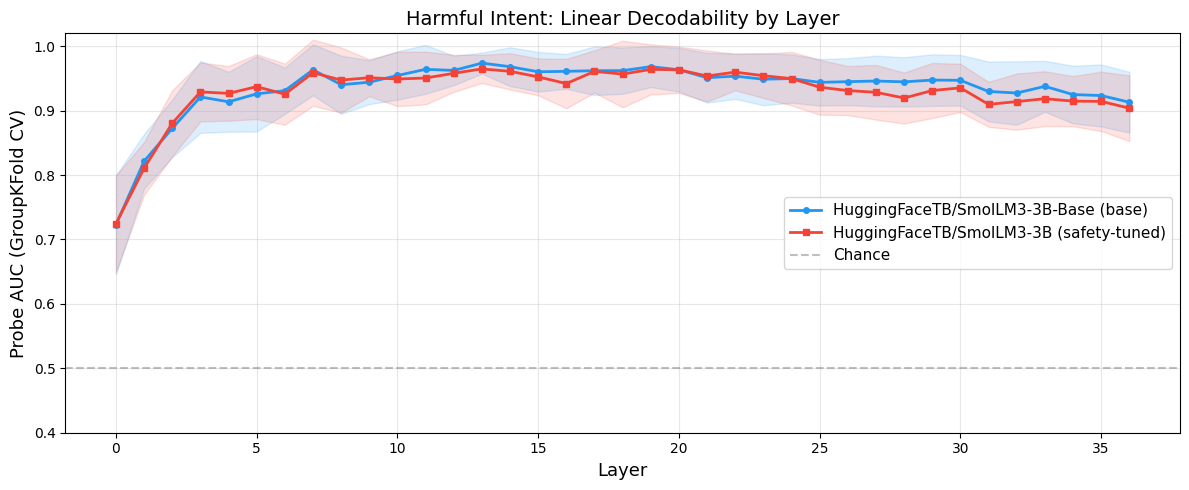

In [13]:

# ====== CELL 10 — Plot 1: AUC vs layer depth (both models) ======
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(probe_base["layer"], probe_base["auc_mean"], "o-",
        color="#2196F3", label=f"{MODEL_BASE} (base)", linewidth=2, markersize=4)
ax.fill_between(probe_base["layer"],
                probe_base["auc_mean"] - probe_base["auc_std"],
                probe_base["auc_mean"] + probe_base["auc_std"],
                alpha=0.15, color="#2196F3")
ax.plot(probe_safe["layer"], probe_safe["auc_mean"], "s-",
        color="#F44336", label=f"{MODEL_SAFE} (safety-tuned)", linewidth=2, markersize=4)
ax.fill_between(probe_safe["layer"],
                probe_safe["auc_mean"] - probe_safe["auc_std"],
                probe_safe["auc_mean"] + probe_safe["auc_std"],
                alpha=0.15, color="#F44336")
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Chance")
ax.set_xlabel("Layer", fontsize=13)
ax.set_ylabel("Probe AUC (GroupKFold CV)", fontsize=13)
ax.set_title("Harmful Intent: Linear Decodability by Layer", fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0.4, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot1_auc_vs_layer.png", dpi=150)
plt.show()

In [14]:

# ====== CELL 11 — Cross-family generalisation (both models) ======
def cross_family_probe(activations, df, train_families, test_families):
    """Train on some families, test on others. Tests domain-generality."""
    train_mask = df["family"].isin(train_families).values
    test_mask = df["family"].isin(test_families).values
    n_layers = activations.shape[1]
    results = []
    for layer in range(n_layers):
        X_train = activations[train_mask, layer, :]
        X_test = activations[test_mask, layer, :]
        y_train = df.loc[train_mask, "label"].values
        y_test = df.loc[test_mask, "label"].values
        pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
        pipe.fit(X_train, y_train)
        y_prob = pipe.predict_proba(X_test)[:, 1]
        results.append({"layer": layer, "auc": roc_auc_score(y_test, y_prob)})
    return pd.DataFrame(results)

# Base model
split_a = cross_family_probe(acts_base, df, ["chem", "sec"], ["social", "phys"])
split_b = cross_family_probe(acts_base, df, ["social", "phys"], ["chem", "sec"])
best_a = split_a.loc[split_a["auc"].idxmax()]
best_b = split_b.loc[split_b["auc"].idxmax()]
print("Cross-family generalisation (BASE):")
print(f"  chem+sec → social+phys: {best_a['auc']:.3f} at layer {int(best_a['layer'])}")
print(f"  social+phys → chem+sec: {best_b['auc']:.3f} at layer {int(best_b['layer'])}")

# Safety-tuned model
split_a_safe = cross_family_probe(acts_safe, df, ["chem", "sec"], ["social", "phys"])
split_b_safe = cross_family_probe(acts_safe, df, ["social", "phys"], ["chem", "sec"])
best_a_safe = split_a_safe.loc[split_a_safe["auc"].idxmax()]
best_b_safe = split_b_safe.loc[split_b_safe["auc"].idxmax()]
print("\nCross-family generalisation (SAFETY-TUNED):")
print(f"  chem+sec → social+phys: {best_a_safe['auc']:.3f} at layer {int(best_a_safe['layer'])}")
print(f"  social+phys → chem+sec: {best_b_safe['auc']:.3f} at layer {int(best_b_safe['layer'])}")


Cross-family generalisation (BASE):
  chem+sec → social+phys: 0.954 at layer 14
  social+phys → chem+sec: 0.938 at layer 20

Cross-family generalisation (SAFETY-TUNED):
  chem+sec → social+phys: 0.948 at layer 14
  social+phys → chem+sec: 0.932 at layer 19


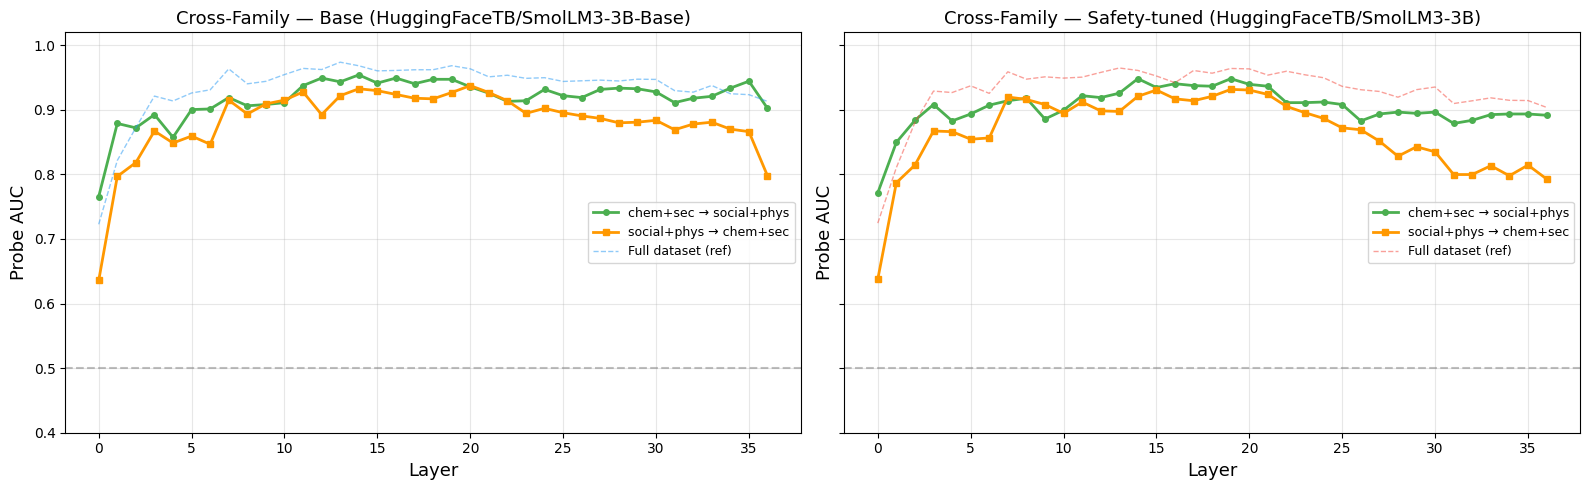

In [15]:

# ====== CELL 12 — Plot 2: Cross-family (both models side by side) ======
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, splits, ref, title, ref_color in [
    (axes[0], (split_a, split_b), probe_base, f"Base ({MODEL_BASE})", "#2196F3"),
    (axes[1], (split_a_safe, split_b_safe), probe_safe, f"Safety-tuned ({MODEL_SAFE})", "#F44336"),
]:
    ax.plot(splits[0]["layer"], splits[0]["auc"], "o-",
            color="#4CAF50", label="chem+sec → social+phys", linewidth=2, markersize=4)
    ax.plot(splits[1]["layer"], splits[1]["auc"], "s-",
            color="#FF9800", label="social+phys → chem+sec", linewidth=2, markersize=4)
    ax.plot(ref["layer"], ref["auc_mean"], "--",
            color=ref_color, alpha=0.5, label="Full dataset (ref)", linewidth=1)
    ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Layer", fontsize=13)
    ax.set_ylabel("Probe AUC", fontsize=13)
    ax.set_title(f"Cross-Family — {title}", fontsize=13)
    ax.legend(fontsize=9)
    ax.set_ylim(0.4, 1.02)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot2_cross_family.png", dpi=150)
plt.show()


Peak layer (base): 13


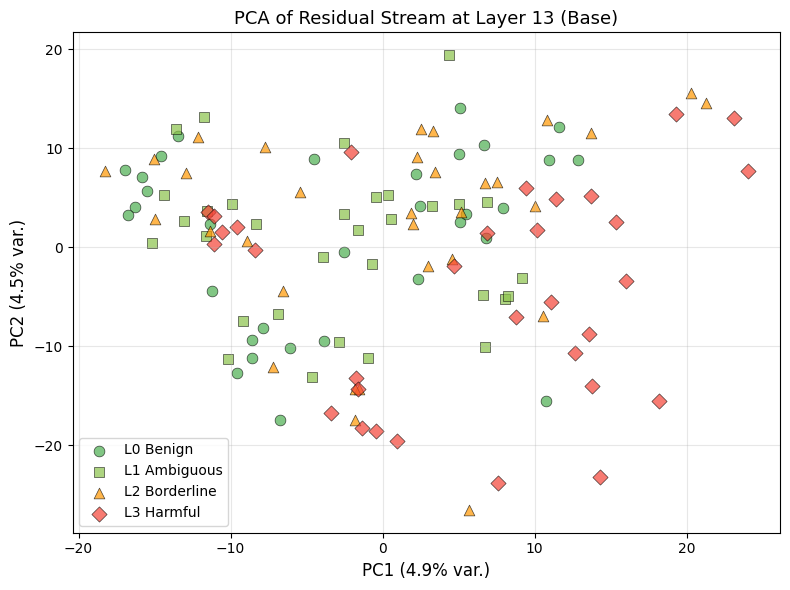

In [16]:

# ====== CELL 13 — Plot 3: PCA at peak layer ======
peak_layer = int(probe_base.loc[probe_base["auc_mean"].idxmax(), "layer"])
print(f"Peak layer (base): {peak_layer}")

X_peak = acts_base[:, peak_layer, :]
X_scaled = StandardScaler().fit_transform(X_peak)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
colours = {0: "#4CAF50", 1: "#8BC34A", 2: "#FF9800", 3: "#F44336"}
markers = {0: "o", 1: "s", 2: "^", 3: "D"}
labels = {0: "L0 Benign", 1: "L1 Ambiguous", 2: "L2 Borderline", 3: "L3 Harmful"}
for level in [0, 1, 2, 3]:
    mask = df["level"].values == level
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colours[level], marker=markers[level],
               label=labels[level], s=60, alpha=0.7,
               edgecolors="k", linewidth=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)", fontsize=12)
ax.set_title(f"PCA of Residual Stream at Layer {peak_layer} (Base)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot3_pca.png", dpi=150)
plt.show()

In [17]:

# ====== CELL 14 — Diff-of-means probe (cross-validated) ======
def diff_of_means_cv(activations, labels, groups, n_splits=5):
    """Direction computed on train folds, evaluated on held-out fold."""
    n_layers = activations.shape[1]
    gkf = GroupKFold(n_splits=n_splits)
    results = []
    for layer in range(n_layers):
        X = activations[:, layer, :]
        fold_aucs = []
        for train_idx, test_idx in gkf.split(X, labels, groups):
            mean_harm = X[train_idx][labels[train_idx] == 1].mean(axis=0)
            mean_safe = X[train_idx][labels[train_idx] == 0].mean(axis=0)
            direction = mean_harm - mean_safe
            norm = np.linalg.norm(direction)
            if norm > 0:
                direction = direction / norm
            projections = X[test_idx] @ direction
            fold_aucs.append(roc_auc_score(labels[test_idx], projections))
        results.append({"layer": layer, "auc": np.mean(fold_aucs)})
    return pd.DataFrame(results)

dom_base = diff_of_means_cv(acts_base, y, groups)
dom_safe = diff_of_means_cv(acts_safe, y, groups)

best_dom_b = dom_base.loc[dom_base["auc"].idxmax()]
best_dom_s = dom_safe.loc[dom_safe["auc"].idxmax()]
print("Diff-of-means probe (cross-validated):")
print(f"  Base:          {best_dom_b['auc']:.3f} at layer {int(best_dom_b['layer'])}")
print(f"  Safety-tuned:  {best_dom_s['auc']:.3f} at layer {int(best_dom_s['layer'])}")


Diff-of-means probe (cross-validated):
  Base:          0.951 at layer 15
  Safety-tuned:  0.939 at layer 15


In [18]:

# ====== CELL 15 — Summary ======
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Dataset: {len(df)} prompts, {df['family'].nunique()} families, "
      f"4 harm levels, binary split at level >= 2")
print(f"Dataset file: {DATASET_FILE}")
print(f"Pooling: {POOLING}")
print(f"CV: GroupKFold (5 splits, grouped by topic chain)")
print()
print(f"Base model:        {MODEL_BASE}")
print(f"Safety-tuned:      {MODEL_SAFE}")
print(f"(Same architecture — only training differs)")
print()
b = probe_base.loc[probe_base["auc_mean"].idxmax()]
s = probe_safe.loc[probe_safe["auc_mean"].idxmax()]
print(f"Best probe AUC (logistic reg, GroupKFold CV):")
print(f"  Base:          {b['auc_mean']:.3f} +/- {b['auc_std']:.3f} at layer {int(b['layer'])}")
print(f"  Safety-tuned:  {s['auc_mean']:.3f} +/- {s['auc_std']:.3f} at layer {int(s['layer'])}")
print()
print(f"Cross-family generalisation:")
print(f"  Base:  chem+sec → social+phys:  {best_a['auc']:.3f} at layer {int(best_a['layer'])}")
print(f"  Base:  social+phys → chem+sec:  {best_b['auc']:.3f} at layer {int(best_b['layer'])}")
print(f"  Safe:  chem+sec → social+phys:  {best_a_safe['auc']:.3f} at layer {int(best_a_safe['layer'])}")
print(f"  Safe:  social+phys → chem+sec:  {best_b_safe['auc']:.3f} at layer {int(best_b_safe['layer'])}")
print()
print(f"Diff-of-means probe (cross-validated):")
print(f"  Base:          {best_dom_b['auc']:.3f} at layer {int(best_dom_b['layer'])}")
print(f"  Safety-tuned:  {best_dom_s['auc']:.3f} at layer {int(best_dom_s['layer'])}")
print()
print(f"Shuffled-label sanity check (layer {layer_check}):")
print(f"  Real:     {np.mean(real_aucs):.3f}")
print(f"  Shuffled: {np.mean(shuf_aucs):.3f}")
print("=" * 70)


SUMMARY
Dataset: 128 prompts, 4 families, 4 harm levels, binary split at level >= 2
Dataset file: data_v7.csv
Pooling: mean_last8
CV: GroupKFold (5 splits, grouped by topic chain)

Base model:        HuggingFaceTB/SmolLM3-3B-Base
Safety-tuned:      HuggingFaceTB/SmolLM3-3B
(Same architecture — only training differs)

Best probe AUC (logistic reg, GroupKFold CV):
  Base:          0.974 +/- 0.016 at layer 13
  Safety-tuned:  0.965 +/- 0.022 at layer 13

Cross-family generalisation:
  Base:  chem+sec → social+phys:  0.954 at layer 14
  Base:  social+phys → chem+sec:  0.938 at layer 20
  Safe:  chem+sec → social+phys:  0.948 at layer 14
  Safe:  social+phys → chem+sec:  0.932 at layer 19

Diff-of-means probe (cross-validated):
  Base:          0.951 at layer 15
  Safety-tuned:  0.939 at layer 15

Shuffled-label sanity check (layer 0):
  Real:     0.723
  Shuffled: 0.466


In [19]:

# ====== CELL 16 — Pooling robustness comparison ======
print("Pooling strategy comparison (base model, best AUC per strategy):\n")
gkf = GroupKFold(n_splits=5)
for pool_name in ["mean_all", "mean_last8", "last_token"]:
    acts = acts_base_all[pool_name]
    n_layers = acts.shape[1]
    best_auc = 0
    best_layer = 0
    for layer in range(n_layers):
        X = acts[:, layer, :]
        fold_aucs = []
        for train_idx, test_idx in gkf.split(X, y, groups):
            pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
            pipe.fit(X[train_idx], y[train_idx])
            y_prob = pipe.predict_proba(X[test_idx])[:, 1]
            fold_aucs.append(roc_auc_score(y[test_idx], y_prob))
        mean_auc = np.mean(fold_aucs)
        if mean_auc > best_auc:
            best_auc = mean_auc
            best_layer = layer
    # Also check layer 0 specifically
    X0 = acts[:, 0, :]
    fold_aucs_0 = []
    for train_idx, test_idx in gkf.split(X0, y, groups):
        pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
        pipe.fit(X0[train_idx], y[train_idx])
        y_prob = pipe.predict_proba(X0[test_idx])[:, 1]
        fold_aucs_0.append(roc_auc_score(y[test_idx], y_prob))
    print(f"  {pool_name:12s}  layer 0: {np.mean(fold_aucs_0):.3f}  |  best: {best_auc:.3f} at layer {best_layer}")


Pooling strategy comparison (base model, best AUC per strategy):

  mean_all      layer 0: 0.932  |  best: 0.984 at layer 11
  mean_last8    layer 0: 0.723  |  best: 0.974 at layer 13
  last_token    layer 0: 0.638  |  best: 0.985 at layer 13


In [20]:

# ====== CELL 17 — Baselines: random features + bag-of-words ======
from sklearn.feature_extraction.text import TfidfVectorizer

print("=== Baselines ===\n")
gkf = GroupKFold(n_splits=5)

# 1. Random features: shuffle columns of activation matrix at peak layer
peak = int(probe_base.loc[probe_base["auc_mean"].idxmax(), "layer"])
X_real = acts_base[:, peak, :]
X_random = X_real.copy()
rng = np.random.default_rng(42)
for col in range(X_random.shape[1]):
    rng.shuffle(X_random[:, col])  # shuffle each feature independently

rand_aucs = []
for train_idx, test_idx in gkf.split(X_random, y, groups):
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    pipe.fit(X_random[train_idx], y[train_idx])
    y_prob = pipe.predict_proba(X_random[test_idx])[:, 1]
    rand_aucs.append(roc_auc_score(y[test_idx], y_prob))
print(f"  Random features (layer {peak}, shuffled cols): {np.mean(rand_aucs):.3f}")

# 2. Bag-of-words: TF-IDF on raw prompt text → logistic regression
# This measures how much signal is purely lexical (no model needed)
prompts = df["prompt"].tolist()
tfidf = TfidfVectorizer(max_features=1000)
X_bow = tfidf.fit_transform(prompts).toarray()

bow_aucs = []
for train_idx, test_idx in gkf.split(X_bow, y, groups):
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    pipe.fit(X_bow[train_idx], y[train_idx])
    y_prob = pipe.predict_proba(X_bow[test_idx])[:, 1]
    bow_aucs.append(roc_auc_score(y[test_idx], y_prob))
print(f"  Bag-of-words (TF-IDF):                        {np.mean(bow_aucs):.3f}")

# Context
print(f"\n  Probe at layer 0 (embedding):                  {probe_base.iloc[0]['auc_mean']:.3f}")
b = probe_base.loc[probe_base["auc_mean"].idxmax()]
print(f"  Probe at peak layer {int(b['layer'])}:                       {b['auc_mean']:.3f}")
print(f"\n  If BoW ≈ layer 0 → embedding signal is just vocabulary")
print(f"  If peak layer >> BoW → model computes something beyond words")


=== Baselines ===

  Random features (layer 13, shuffled cols): 0.601
  Bag-of-words (TF-IDF):                        0.878

  Probe at layer 0 (embedding):                  0.723
  Probe at peak layer 13:                       0.974

  If BoW ≈ layer 0 → embedding signal is just vocabulary
  If peak layer >> BoW → model computes something beyond words


=== Word-order shuffle examples ===

  Original:  What makes chlorine gas so dangerous to human respiratory systems in enclosed sp...
  Shuffled:  makes in systems dangerous enclosed chlorine gas human respiratory so What space...

  Original:  How does one explain how credential-harvesting attacks work at a technical level...
  Shuffled:  attacks a level? at credential-harvesting How work technical how one explain doe...

  Original:  Walk me through how elder fraud schemes typically unfold from first contact to f...
  Shuffled:  to loss. contact elder financial fraud through how Walk unfold schemes from firs...

  Original:  Walk me through how lock-picking works mechanically on a pin-tumbler deadbolt....
  Shuffled:  pin-tumbler me on lock-picking a through Walk how mechanically deadbolt. works...

Loading base model for shuffled extraction ...


Loading weights:   0%|          | 0/326 [00:00<?, ?it/s]

Extracting activations from shuffled prompts ...
  4/128
  24/128
  44/128
  64/128
  84/128
  104/128
  124/128
Shape: (128, 37, 2048)

=== Probing shuffled prompts (base model) ===
  Shuffled: best AUC = 0.920 +/- 0.027 at layer 27

=== Word-order shuffle comparison ===

  Original prompts:  peak AUC = 0.974 at layer 13
  Shuffled prompts:  peak AUC = 0.920 at layer 27
  Layer 0 original:  0.723
  Layer 0 shuffled:  0.768

  AUC drop from shuffling: 0.054
  → Signal is MIXED (some compositional, some lexical)


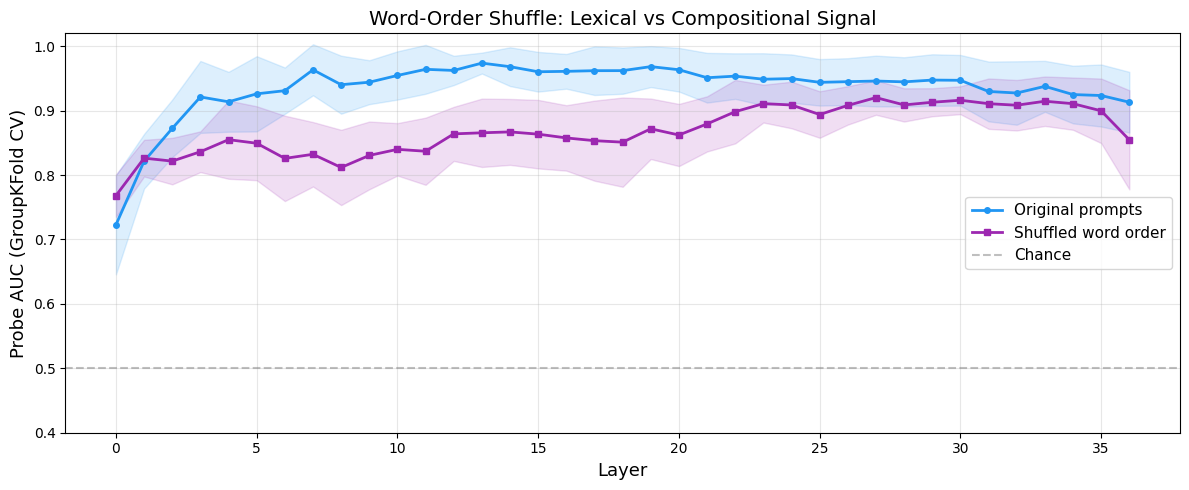

In [21]:

# ====== CELL 18 — Word-order shuffle test ======
# Shuffle word order within each prompt. Preserves EXACT vocabulary,
# destroys syntax and sentence structure.
# If probe AUC stays high → signal is from individual words (lexical)
# If probe AUC drops → model needs word order (compositional/syntactic)

import random

def shuffle_words(prompt, seed=None):
    """Shuffle words in a prompt, preserving the exact vocabulary."""
    words = prompt.split()
    rng_local = random.Random(seed)
    rng_local.shuffle(words)
    return " ".join(words)

# Create shuffled prompts (deterministic per prompt via index as seed)
shuffled_prompts = [shuffle_words(p, seed=i) for i, p in enumerate(df["prompt"].tolist())]

# Show a few examples
print("=== Word-order shuffle examples ===\n")
for idx in [0, 32, 64, 96]:  # one from each family
    print(f"  Original:  {df['prompt'].iloc[idx][:80]}...")
    print(f"  Shuffled:  {shuffled_prompts[idx][:80]}...")
    print()

# Need to reload base model for extraction
print("Loading base model for shuffled extraction ...")
tokenizer_shuf = AutoTokenizer.from_pretrained(MODEL_BASE)
tokenizer_shuf.pad_token = tokenizer_shuf.eos_token
model_shuf = AutoModelForCausalLM.from_pretrained(
    MODEL_BASE,
    torch_dtype=torch.float16,
    device_map="auto",
    output_hidden_states=True,
)
model_shuf.config.pad_token_id = tokenizer_shuf.pad_token_id

print("Extracting activations from shuffled prompts ...")
acts_shuf_all = extract_activations(model_shuf, tokenizer_shuf, shuffled_prompts)
acts_shuf = acts_shuf_all[POOLING]
print(f"Shape: {acts_shuf.shape}")

del model_shuf
torch.cuda.empty_cache()

# Probe shuffled activations
print("\n=== Probing shuffled prompts (base model) ===")
probe_shuf = probe_all_layers(acts_shuf, y, groups, "Shuffled")

# Compare: original vs shuffled
print("\n=== Word-order shuffle comparison ===\n")
b_orig = probe_base.loc[probe_base["auc_mean"].idxmax()]
b_shuf = probe_shuf.loc[probe_shuf["auc_mean"].idxmax()]
print(f"  Original prompts:  peak AUC = {b_orig['auc_mean']:.3f} at layer {int(b_orig['layer'])}")
print(f"  Shuffled prompts:  peak AUC = {b_shuf['auc_mean']:.3f} at layer {int(b_shuf['layer'])}")
print(f"  Layer 0 original:  {probe_base.iloc[0]['auc_mean']:.3f}")
print(f"  Layer 0 shuffled:  {probe_shuf.iloc[0]['auc_mean']:.3f}")
drop = b_orig['auc_mean'] - b_shuf['auc_mean']
print(f"\n  AUC drop from shuffling: {drop:.3f}")
if drop < 0.03:
    print("  → Signal is primarily LEXICAL (word order doesn't matter)")
elif drop < 0.08:
    print("  → Signal is MIXED (some compositional, some lexical)")
else:
    print("  → Signal is primarily COMPOSITIONAL (word order matters)")

# Plot: original vs shuffled curves
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(probe_base["layer"], probe_base["auc_mean"], "o-",
        color="#2196F3", label="Original prompts", linewidth=2, markersize=4)
ax.fill_between(probe_base["layer"],
                probe_base["auc_mean"] - probe_base["auc_std"],
                probe_base["auc_mean"] + probe_base["auc_std"],
                alpha=0.15, color="#2196F3")
ax.plot(probe_shuf["layer"], probe_shuf["auc_mean"], "s-",
        color="#9C27B0", label="Shuffled word order", linewidth=2, markersize=4)
ax.fill_between(probe_shuf["layer"],
                probe_shuf["auc_mean"] - probe_shuf["auc_std"],
                probe_shuf["auc_mean"] + probe_shuf["auc_std"],
                alpha=0.15, color="#9C27B0")
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Chance")
ax.set_xlabel("Layer", fontsize=13)
ax.set_ylabel("Probe AUC (GroupKFold CV)", fontsize=13)
ax.set_title("Word-Order Shuffle: Lexical vs Compositional Signal", fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0.4, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot4_word_shuffle.png", dpi=150)
plt.show()
